# Traffic Demand Prediction Pipeline

This notebook demonstrates a complete step-by-step pipeline:
1. Data Exploration
2. Data Visualization
3. Feature Engineering
4. Building Framework & Training Model
5. Testing & Submission

## 1. Data Exploration
Let's load the data, view its structure, and compute summary statistics.

In [6]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings('ignore')

def parse_time(df):
    df = df.copy()
    def ts_to_minutes(ts):
        if pd.isna(ts):
            return np.nan
        h, m = map(int, str(ts).split(':'))
        return h * 60 + m
    
    df['minutes'] = df['timestamp'].apply(ts_to_minutes)
    df['slot'] = (df['minutes'] / 15).astype(int)
    df['time_seq'] = df['day'] * 96 + df['slot']
    df['hour'] = df['timestamp'].apply(lambda x: int(x.split(':')[0]))
    df['minute'] = df['timestamp'].apply(lambda x: int(x.split(':')[1]))
    return df

train_df = pd.read_csv('dataset/train.csv')
train_df = parse_time(train_df)

cat_cols = ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'geohash']
for col in cat_cols:
    train_df[col] = train_df[col].fillna('missing').astype(str)

train_df['Temperature'] = train_df['Temperature'].astype(float)
train_df['NumberofLanes'] = train_df['NumberofLanes'].astype(float)
train_df['demand'] = train_df['demand'].astype(float)

display(train_df.head())
display(train_df.info())
display(train_df.describe())

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,minutes,slot,time_seq,hour,minute
0,0,qp02z1,48,0:0,0.048804,missing,1.0,Not Allowed,No,NaN,missing,0,0,4608,0,0
1,1,qp02zt,48,0:0,0.118507,Residential,3.0,Allowed,Yes,31.104565,Sunny,0,0,4608,0,0
2,2,qp08bj,48,0:0,0.027132,Residential,1.0,Not Allowed,No,25.919267,Sunny,0,0,4608,0,0
3,3,qp08gt,48,0:0,0.003272,Residential,1.0,Not Allowed,No,NaN,Rainy,0,0,4608,0,0
4,4,qp02zq,48,0:0,0.010819,Residential,1.0,Not Allowed,No,10.803667,Rainy,0,0,4608,0,0


<class 'pandas.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  str    
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  str    
 4   demand         77299 non-null  float64
 5   RoadType       77299 non-null  str    
 6   NumberofLanes  77299 non-null  float64
 7   LargeVehicles  77299 non-null  str    
 8   Landmarks      77299 non-null  str    
 9   Temperature    74804 non-null  float64
 10  Weather        77299 non-null  str    
 11  minutes        77299 non-null  int64  
 12  slot           77299 non-null  int64  
 13  time_seq       77299 non-null  int64  
 14  hour           77299 non-null  int64  
 15  minute         77299 non-null  int64  
dtypes: float64(3), int64(7), str(6)
memory usage: 9.4 MB


None

,Index,day,demand,NumberofLanes,Temperature,minutes,slot,time_seq,hour,minute
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000,77299.000000,77299.000000,77299.000000,77299.000000,77299.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354,568.352113,37.890141,4655.666619,9.101347,22.271310
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835,411.957302,27.463820,30.587978,6.856045,16.853641
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097,0.000000,0.000000,4608.000000,0.000000,0.000000
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473,195.000000,13.000000,4630.000000,3.000000,0.000000
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587,525.000000,35.000000,4652.000000,8.000000,15.000000
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833,855.000000,57.000000,4679.000000,14.000000,30.000000
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433,1425.000000,95.000000,4712.000000,23.000000,45.000000


## 2. Data Visualization
Let's visualize the target variable and its relationship with some features.

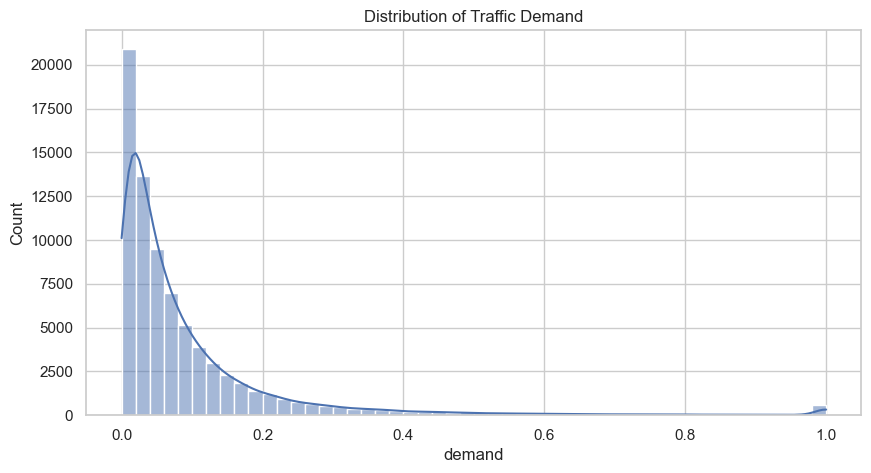

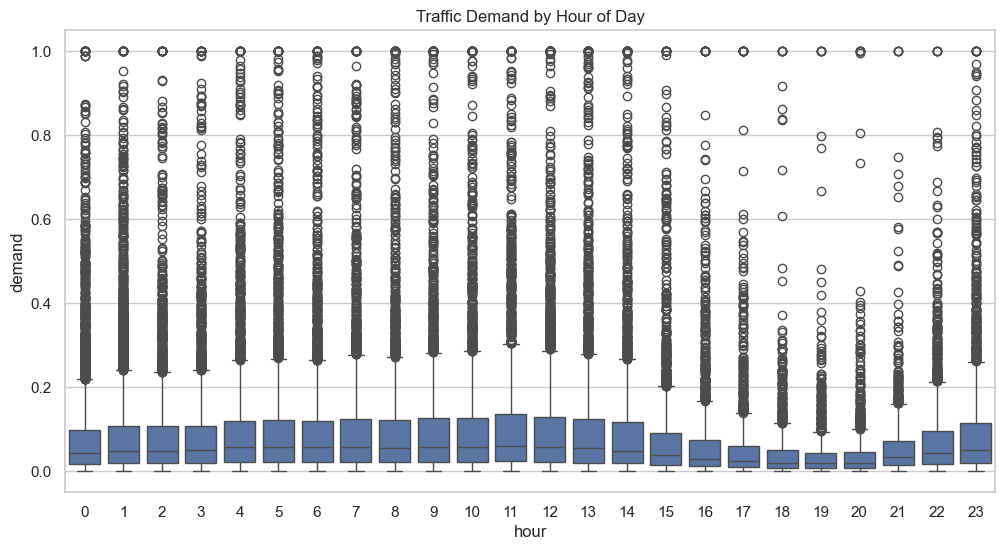

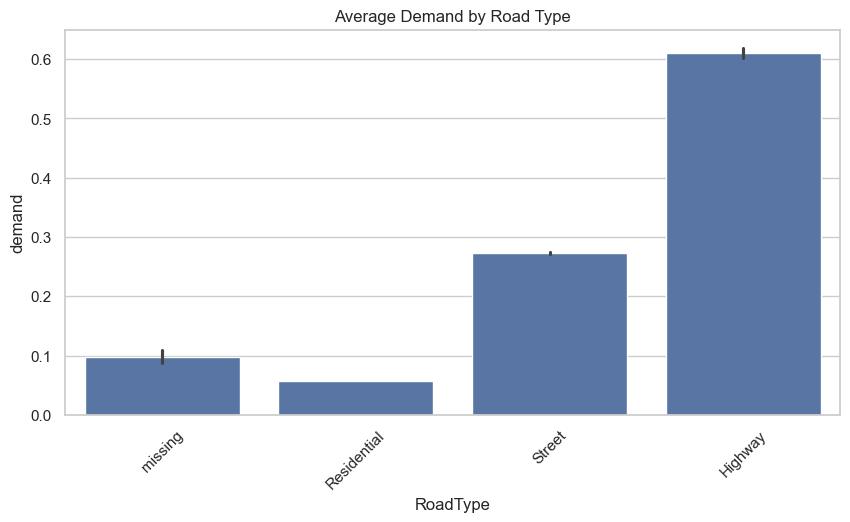

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df['demand'], bins=50, kde=True)
plt.title('Distribution of Traffic Demand')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='hour', y='demand', data=train_df)
plt.title('Traffic Demand by Hour of Day')
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x='RoadType', y='demand', data=train_df)
plt.title('Average Demand by Road Type')
plt.xticks(rotation=45)
plt.show()

## 3. Feature Engineering
Creating time-based cyclical features and missing value indicators.

In [8]:
def add_time_features(df):
    df = df.copy()
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
    min_in_day = df['hour'] * 60 + df['minute']
    df['minute_sin'] = np.sin(2 * np.pi * min_in_day / 1440.0)
    df['minute_cos'] = np.cos(2 * np.pi * min_in_day / 1440.0)
    df['slot_15'] = (min_in_day / 15).astype(int)
    def get_tod_bucket(h):
        if 0 <= h < 6: return 'night'
        elif 6 <= h < 12: return 'morning'
        elif 12 <= h < 18: return 'afternoon'
        else: return 'evening'
    df['time_of_day'] = df['hour'].apply(get_tod_bucket).astype('category')
    new_cols = ['hour_sin', 'hour_cos', 'minute_sin', 'minute_cos', 'slot_15', 'time_of_day']
    return df, new_cols

def add_missing_features(df):
    df = df.copy()
    df['Weather_missing'] = df['Weather'].apply(lambda x: 1 if x == 'missing' or pd.isna(x) else 0)
    df['RoadType_missing'] = df['RoadType'].apply(lambda x: 1 if x == 'missing' or pd.isna(x) else 0)
    df['Temperature_missing'] = df['Temperature'].isna().astype(int)
    new_cols = ['Weather_missing', 'RoadType_missing', 'Temperature_missing']
    return df, new_cols

df_feat, new_a = add_time_features(train_df)
df_feat, new_d = add_missing_features(df_feat)

base_features = [
    'day', 'hour', 'minute', 'RoadType', 'LargeVehicles', 
    'Landmarks', 'Weather', 'Temperature', 'NumberofLanes', 'geohash'
]
features = base_features + new_a + new_d
cat_features = ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'geohash', 'time_of_day']

for col in cat_features:
    df_feat[col] = df_feat[col].astype(str)

## 4. Building Framework & Training Model
Setup Walk-Forward Validation and train CatBoost baseline.

In [9]:
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score

class WalkForwardValidation:
    def __init__(self, validation_window_slots=8, gap_slots=4, train_window_slots=None, n_splits=3):
        self.validation_window_slots = validation_window_slots
        self.gap_slots = gap_slots
        self.train_window_slots = train_window_slots
        self.n_splits = n_splits

    def split(self, df):
        df = df.copy().reset_index(drop=True)
        unique_seqs = sorted(df['time_seq'].unique())
        total_slots = len(unique_seqs)
        
        splits = []
        current_end_idx = total_slots - 1
        
        for fold in range(self.n_splits):
            val_end_seq = unique_seqs[current_end_idx]
            val_start_seq = unique_seqs[max(0, current_end_idx - self.validation_window_slots + 1)]
            
            gap_end_seq = val_start_seq - 1
            gap_start_seq = gap_end_seq - self.gap_slots + 1
            train_end_seq = gap_start_seq - 1
            
            if self.train_window_slots is not None:
                train_start_seq = max(unique_seqs[0], train_end_seq - self.train_window_slots + 1)
            else:
                train_start_seq = unique_seqs[0]
                
            if train_end_seq < train_start_seq:
                break
                
            train_idx = df[(df['time_seq'] >= train_start_seq) & (df['time_seq'] <= train_end_seq)].index.values
            val_idx = df[(df['time_seq'] >= val_start_seq) & (df['time_seq'] <= val_end_seq)].index.values
            
            splits.insert(0, (train_idx, val_idx, (train_start_seq, train_end_seq), (val_start_seq, val_end_seq)))
            current_end_idx -= self.validation_window_slots
            
        return splits

print("Training Model (CatBoost)... ")
wfv = WalkForwardValidation(validation_window_slots=8, gap_slots=4, train_window_slots=None, n_splits=3)
splits = wfv.split(df_feat)

for fold, (train_idx, val_idx, _, _) in enumerate(splits):
    X_train, y_train = df_feat.loc[train_idx, features], df_feat.loc[train_idx, 'demand']
    X_val, y_val = df_feat.loc[val_idx, features], df_feat.loc[val_idx, 'demand']
    
    model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        cat_features=cat_features,
        random_seed=42,
        verbose=100
    )
    model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
    preds = model.predict(X_val)
    score = max(0, 100 * r2_score(y_val, preds))
    print(f"Fold {fold+1} Score: {score:.4f}")

Training Model (CatBoost)... 
0:	learn: 0.1409075	test: 0.0919398	best: 0.0919398 (0)	total: 19.6ms	remaining: 9.8s
100:	learn: 0.0415099	test: 0.0422955	best: 0.0420300 (70)	total: 839ms	remaining: 3.31s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.042029977
bestIteration = 70

Shrink model to first 71 iterations.
Fold 1 Score: 75.4833
0:	learn: 0.1392896	test: 0.1176369	best: 0.1176369 (0)	total: 14.9ms	remaining: 7.41s
100:	learn: 0.0420776	test: 0.0622646	best: 0.0593464 (52)	total: 862ms	remaining: 3.41s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.05934639971
bestIteration = 52

Shrink model to first 53 iterations.
Fold 2 Score: 76.7053
0:	learn: 0.1368830	test: 0.1397948	best: 0.1397948 (0)	total: 11.4ms	remaining: 5.7s
100:	learn: 0.0426972	test: 0.0594376	best: 0.0588022 (76)	total: 922ms	remaining: 3.64s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.05880223849
bestIteration = 76

Shrink model to first 77 ite

## 5. Testing & Submission
Predicting on test data and generating `submission.csv`.

In [10]:
test_df = pd.read_csv('dataset/test.csv')
test_df = parse_time(test_df)
for col in ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'geohash']:
    test_df[col] = test_df[col].fillna('missing').astype(str)
test_df['Temperature'] = test_df['Temperature'].astype(float)
test_df['NumberofLanes'] = test_df['NumberofLanes'].astype(float)

test_df, _ = add_time_features(test_df)
test_df, _ = add_missing_features(test_df)

X_train_full = df_feat[features]
y_train_full = df_feat['demand']
X_test_full = test_df[features]

for col in cat_features:
    X_train_full[col] = X_train_full[col].astype(str)
    X_test_full[col] = X_test_full[col].astype(str)

final_model = CatBoostRegressor(
    iterations=600,
    learning_rate=0.05,
    depth=6,
    cat_features=cat_features,
    random_seed=42,
    verbose=0
)
final_model.fit(X_train_full, y_train_full)
test_preds = final_model.predict(X_test_full)
test_preds = np.clip(test_preds, y_train_full.min(), y_train_full.max())

submission = pd.DataFrame({
    'Index': test_df['Index'],
    'demand': test_preds
})
submission.to_csv('submission.csv', index=False)
print("Submission generated successfully!")
display(submission.head())

Submission generated successfully!


,Index,demand
0,0,0.036163
1,1,0.019346
2,2,0.004774
3,3,0.033953
4,4,0.054686
